In [27]:
from langgraph.graph import StateGraph , START , END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict , Annotated
from pydantic import BaseModel , Field
import operator

In [28]:
load_dotenv()

True

In [29]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.7)

In [30]:
class EvaluationSchema(BaseModel):
    
    feedback : str = Field(description="Detailed feedback on the essay")
    score : int = Field(description="Score out of 10 for the essay" , ge=0 , le=10) 

In [31]:
structured_model = model.with_structured_output(EvaluationSchema)

In [32]:
## Role of Politicians in the Development of India

essay = """The development of a nation is not an accidental process; it is shaped by decisions, priorities, and the quality of leadership guiding it. In India, politicians play a central role in determining the direction and pace of development. From framing policies to implementing large-scale programs, their actions directly influence economic growth, social progress, and institutional strength.

At the core, politicians are responsible for **policy-making and governance**. Through legislative bodies like the Parliament and State Assemblies, they design laws that regulate industries, promote investment, and ensure social welfare. Policies related to taxation, infrastructure, education, healthcare, and technology all originate from political decision-making. For example, initiatives aimed at digitalization, infrastructure expansion, and startup ecosystems have significantly contributed to India’s economic transformation in recent years. Effective politicians understand ground realities and design policies that balance growth with inclusivity.

Another crucial role is **resource allocation and prioritization**. India, being a developing country with vast population and diverse needs, cannot address all challenges simultaneously. Politicians decide where funds should be directed—whether toward rural development, urban infrastructure, defense, or social welfare schemes. The quality of these decisions determines whether development is balanced or skewed. Regions with strong political representation often see better infrastructure, highlighting how political focus can shape local development outcomes.

Politicians also act as a **bridge between the government and citizens**. They represent the concerns, needs, and aspirations of the people. Through constituency work, public meetings, and grievance redressal, they ensure that voices from the ground influence national and state-level decisions. This representative function is essential in a democracy like India, where diversity in language, culture, and economic status requires inclusive governance.

Equally important is their role in **implementing and monitoring schemes**. Policies alone do not ensure development; execution does. Politicians oversee administrative machinery, ensure accountability, and push for timely completion of projects. Whether it is building roads, improving public healthcare, or implementing employment schemes, political will often determines success or failure. Strong leadership can accelerate projects, while weak or corrupt leadership can stall progress.

However, the role of politicians is not without challenges and criticism. Issues such as corruption, short-term populism, and vote-bank politics often hinder long-term development. Instead of focusing on sustainable growth, some leaders prioritize immediate electoral gains, leading to inefficient use of resources. Moreover, lack of accountability and transparency can slow down reforms and reduce public trust. Therefore, the impact of politicians on development is highly dependent on their integrity, vision, and commitment.

On the positive side, visionary political leadership has historically driven major transformations in India. From economic liberalization to advancements in infrastructure and technology, strong policy decisions have played a decisive role in shaping modern India. When politicians focus on long-term national interest rather than short-term gains, they become powerful agents of change.

In conclusion, politicians are key architects of India’s development. Their decisions influence every aspect of national progress—from economic growth to social equity. While challenges exist, the potential for positive impact is immense when leadership is driven by accountability, vision, and public welfare. Ultimately, the future of India’s development depends not just on policies, but on the quality of political leadership guiding the nation."""


In [33]:
prompt = f"""Evaluate the following essay on the topic "Role of Politicians in the Development of India". Provide detailed feedback and a score out of 10 based on the content, structure, clarity, and relevance of the essay.{essay}"""
structured_model.invoke(prompt)

EvaluationSchema(feedback="The essay provides a comprehensive and well-structured analysis of the role of politicians in India's development. The introduction effectively sets the stage, and the body paragraphs logically delve into various crucial aspects such as policy-making, resource allocation, representation, and scheme implementation. The essay demonstrates strong clarity in its arguments and uses relevant examples to support its points, such as digitalization initiatives and infrastructure expansion. A significant strength is the balanced perspective, acknowledging not only the positive impact of visionary leadership but also the challenges posed by corruption, populism, and short-term political gains. The language is clear, concise, and academic, making the essay easy to follow and understand. The conclusion effectively summarizes the main arguments and reinforces the central thesis. To elevate it further, one could consider including more specific historical examples of how po

In [34]:
class UPSCState(TypedDict):
    essay : str
    language_feedback : str
    analytical_feedback : str
    clarity_feedback : str
    overall_feedback : str
    individual_scores : Annotated[list[int] , operator.add]
    avg_score : float

In [35]:
graph = StateGraph(UPSCState)

In [36]:
def evalute_language(state : UPSCState) -> UPSCState:
    prompt = f"""Evaluate the language and grammar of the following essay. Provide detailed feedback and a score out of 10 based on the correctness, fluency, and appropriateness of the language used in the essay.{state['essay']}"""
    output = structured_model.invoke(prompt)
    
    return {"language_feedback" : output.feedback , "individual_scores" : [output.score]}

In [37]:
def evaluate_analysis(state : UPSCState) -> UPSCState:
    prompt = f"""Evaluate the analytical depth of the following essay. Provide detailed feedback and a score out of 10 based on the quality of arguments, evidence, and critical thinking demonstrated in the essay.{state['essay']}"""
    output = structured_model.invoke(prompt)
    
    return {"analytical_feedback" : output.feedback , "individual_scores" : [output.score]}

In [38]:
def evaluate_clarity(state: UPSCState) -> UPSCState:
    prompt = f"""Evaluate the clarity of thought in the following essay. Provide detailed feedback and a score out of 10 based on the coherence, organization, and logical flow of ideas in the essay.{state['essay']}"""
    output = structured_model.invoke(prompt)
    
    return {"clarity_feedback" : output.feedback , "individual_scores" : [output.score]}

In [39]:
def evaluate_overall(state: UPSCState) -> UPSCState:
    prompt = f"""Based on the following feedbacks create a summarized feedback \n language feedback : {state['language_feedback']} \n analytical feedback : {state['analytical_feedback']} \n clarity feedback : {state['clarity_feedback']} """
    overall_output = model.invoke(prompt).content
    
    #avg calculation
    avg_score = sum(state['individual_scores']) / len(state['individual_scores'])
    return {"overall_feedback" : overall_output , "avg_score" : avg_score}

In [40]:
graph.add_node("evaluate_language" , evalute_language)
graph.add_node("evaluate_analysis" , evaluate_analysis)
graph.add_node("evaluate_clarity" , evaluate_clarity)
graph.add_node("evaluate_overall" , evaluate_overall)


In [41]:
#edges
graph.add_edge(START , "evaluate_language")
graph.add_edge(START , "evaluate_analysis")
graph.add_edge(START , "evaluate_clarity")

graph.add_edge("evaluate_language" , "evaluate_overall")
graph.add_edge("evaluate_analysis" , "evaluate_overall")
graph.add_edge("evaluate_clarity" , "evaluate_overall")
graph.add_edge("evaluate_overall" , END)

workflow = graph.compile()

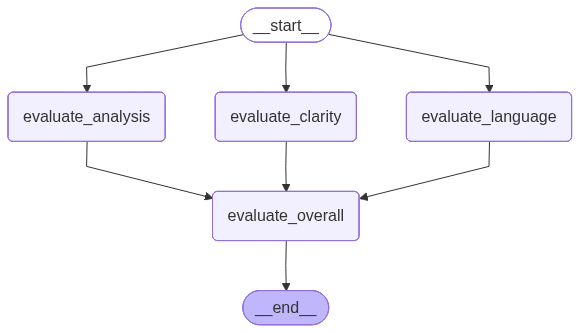

In [42]:
workflow

In [43]:
initial_state = {
    "essay" : essay
}

workflow.invoke(initial_state)  

{'essay': 'The development of a nation is not an accidental process; it is shaped by decisions, priorities, and the quality of leadership guiding it. In India, politicians play a central role in determining the direction and pace of development. From framing policies to implementing large-scale programs, their actions directly influence economic growth, social progress, and institutional strength.\n\nAt the core, politicians are responsible for **policy-making and governance**. Through legislative bodies like the Parliament and State Assemblies, they design laws that regulate industries, promote investment, and ensure social welfare. Policies related to taxation, infrastructure, education, healthcare, and technology all originate from political decision-making. For example, initiatives aimed at digitalization, infrastructure expansion, and startup ecosystems have significantly contributed to India’s economic transformation in recent years. Effective politicians understand ground realit